# 1. Importar Librerías.

In [270]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

# Librerías de Scikit-Learn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
roc_curve, roc_auc_score, confusion_matrix, classification_report, cohen_kappa_score
)

# 2. Cargar los datos.

In [271]:
# Cargar datos
data = pd.read_csv("TCGA_InfoWithGrade_clean.csv") 

In [272]:
# Ver estructura
print(data.head())

   Grade  Gender  Age_at_diagnosis  Race  IDH1  TP53  ATRX  PTEN  EGFR  CIC  \
0      0       0             51.30     0     1     0     0     0     0    0   
1      0       0             38.72     0     1     0     0     0     0    1   
2      0       0             35.17     0     1     1     1     0     0    0   
3      0       1             32.78     0     1     1     1     0     0    0   
4      0       0             31.51     0     1     1     1     0     0    0   

   ...  FUBP1  RB1  NOTCH1  BCOR  CSMD3  SMARCA4  GRIN2A  IDH2  FAT4  PDGFRA  
0  ...      1    0       0     0      0        0       0     0     0       0  
1  ...      0    0       0     0      0        0       0     0     0       0  
2  ...      0    0       0     0      0        0       0     0     0       0  
3  ...      0    0       0     0      0        0       0     0     1       0  
4  ...      0    0       0     0      0        0       0     0     0       0  

[5 rows x 24 columns]


# 3. Definición de variables y conjuntos de datos.

In [273]:
# Frecuencia de mutación por gen (EDA)
selected_genes = ["IDH1","TP53","ATRX","PTEN","EGFR"]

In [274]:
# Reducción de 5 a 3 mejores según EDA
top_genes = ["IDH1", "TP53", "ATRX"]

In [275]:
# Reccorre todas las variables moleculares excluyendo 
# la variable objetivo y las clínicas
all_genes = [col for col in data.columns 
             if col not in ["Grade", "Age_at_diagnosis", "Gender", "Race"]]
              
             

In [276]:
# Utilizamos solo estas tres columnas de las variables clínicas
clinical_var = ["Age_at_diagnosis", "Gender", "Race"]

In [277]:
selected_genes_features = selected_genes # los 5 mejores genes de EDA
top_genes_features = top_genes
all_genes_features = all_genes # todos los genes lo dejo 
clinical_molecular_selected_genes = selected_genes + clinical_var # genes más frecuentes + variables clínicas
clinical_molecular_top_genes = top_genes + clinical_var # solo los 3 genes que son más relevantes según EDA
clinical_only = clinical_var

In [278]:
# features_C sin IDH1
selected_genes_no_IDH1 = [col for col in clinical_molecular_selected_genes if col != "IDH1"]

In [279]:
datasets = {
    "selected_genes": selected_genes_features,
    "top_genes": top_genes_features,
    "all_genes": all_genes_features,
    "clinical_molecular_selected_genes": clinical_molecular_selected_genes,
    "No_IDH1_1" : selected_genes_no_IDH1, 
    "clinical_molecular_top_genes" : clinical_molecular_top_genes,
    "clinical_only": clinical_var
}

In [280]:
# Variable objetivo
y = data["Grade"]

# 4. Métricas de evaluación

In [281]:
def evaluate_model(name, model, X_test, y_test, dataset_name):

    y_pred = model.predict(X_test) # Predicción 
    y_prob = model.predict_proba(X_test)[:,1] # Probabilidad

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Sensibilidad
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    print(f"\n ==========================")
    print(f" Dataset: {dataset_name}")
    print(f" Model: {name}")
    print("==========================")

    print("Accuracy:", round(acc,3))
    print("Precision:", round(prec,3))
    print("Recall (Sensibilidad):", round(rec,3))
    print("F1-score:", round(f1,3))
    print("Kappa:", round(kappa,3))
    print("AUC:", round(auc,3))
    print("Specificity:", round(spec,3))

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n Classification Report:\n", classification_report(y_test, y_pred))

    # Guardar los resultados
    results.append({
        "Dataset": dataset_name,
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Sensitivity": rec,
        "F1": f1,
        "Kappa": kappa,
        "AUC": auc,
        "Specificity": spec
    })

# 5. Entrenamiento, selección de modelos y evaluación

CROSS-VALIDATION (AUC)
Logistic: 0.872 ± 0.023
LASSO: 0.869 ± 0.021
SVM: 0.872 ± 0.024
RandomForest: 0.888 ± 0.015
XGBoost: 0.891 ± 0.014

 Mejor modelo (CV): XGBoost

 Test evaluation

 Dataset: selected_genes
 Model: XGBoost
Accuracy: 0.875
Precision: 0.798
Recall (Sensibilidad): 0.944
F1-score: 0.865
Kappa: 0.75
AUC: 0.907
Specificity: 0.825
Confusion Matrix:
 [[80 17]
 [ 4 67]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88        97
           1       0.80      0.94      0.86        71

    accuracy                           0.88       168
   macro avg       0.88      0.88      0.87       168
weighted avg       0.89      0.88      0.88       168



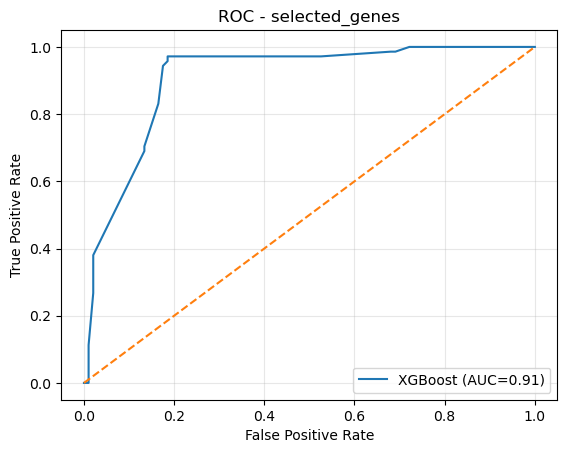

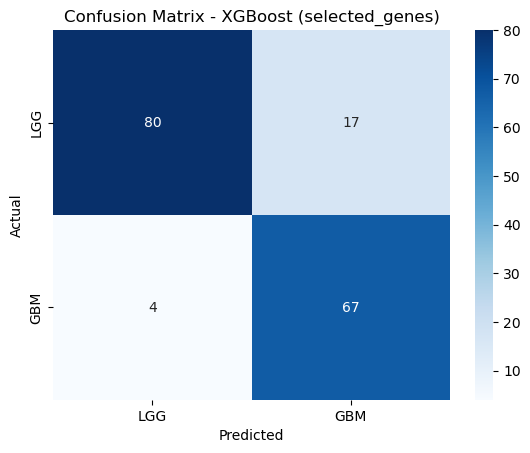

CROSS-VALIDATION (AUC)
Logistic: 0.871 ± 0.016
LASSO: 0.870 ± 0.016
SVM: 0.857 ± 0.031
RandomForest: 0.882 ± 0.020
XGBoost: 0.884 ± 0.020

 Mejor modelo (CV): XGBoost

 Test evaluation

 Dataset: top_genes
 Model: XGBoost
Accuracy: 0.869
Precision: 0.795
Recall (Sensibilidad): 0.93
F1-score: 0.857
Kappa: 0.738
AUC: 0.914
Specificity: 0.825
Confusion Matrix:
 [[80 17]
 [ 5 66]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88        97
           1       0.80      0.93      0.86        71

    accuracy                           0.87       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.87      0.87       168



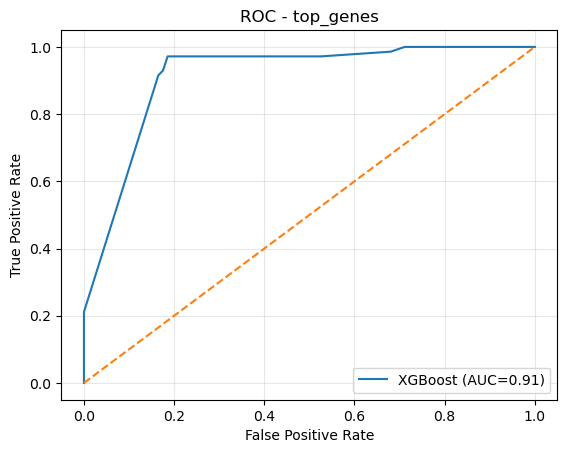

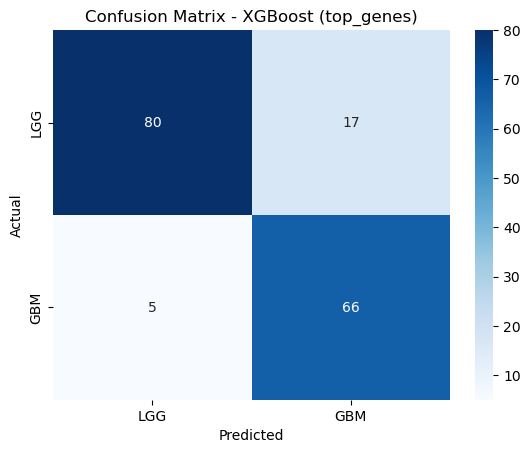

CROSS-VALIDATION (AUC)
Logistic: 0.907 ± 0.011
LASSO: 0.906 ± 0.012
SVM: 0.888 ± 0.015
RandomForest: 0.914 ± 0.019
XGBoost: 0.920 ± 0.017

 Mejor modelo (CV): XGBoost

 Test evaluation

 Dataset: all_genes
 Model: XGBoost
Accuracy: 0.881
Precision: 0.807
Recall (Sensibilidad): 0.944
F1-score: 0.87
Kappa: 0.761
AUC: 0.913
Specificity: 0.835
Confusion Matrix:
 [[81 16]
 [ 4 67]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89        97
           1       0.81      0.94      0.87        71

    accuracy                           0.88       168
   macro avg       0.88      0.89      0.88       168
weighted avg       0.89      0.88      0.88       168



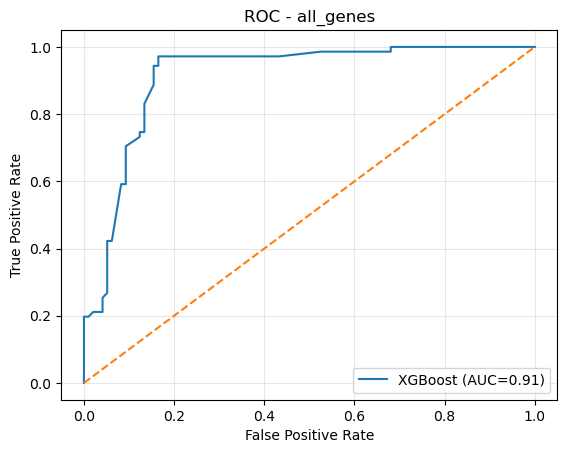

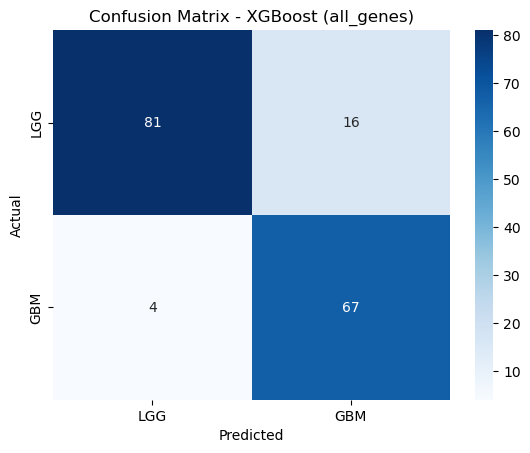

CROSS-VALIDATION (AUC)
Logistic: 0.900 ± 0.019
LASSO: 0.900 ± 0.020
SVM: 0.898 ± 0.032
RandomForest: 0.868 ± 0.032
XGBoost: 0.874 ± 0.028

 Mejor modelo (CV): LASSO

 Test evaluation

 Dataset: clinical_molecular_selected_genes
 Model: LASSO
Accuracy: 0.893
Precision: 0.835
Recall (Sensibilidad): 0.93
F1-score: 0.88
Kappa: 0.784
AUC: 0.948
Specificity: 0.866
Confusion Matrix:
 [[84 13]
 [ 5 66]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90        97
           1       0.84      0.93      0.88        71

    accuracy                           0.89       168
   macro avg       0.89      0.90      0.89       168
weighted avg       0.90      0.89      0.89       168



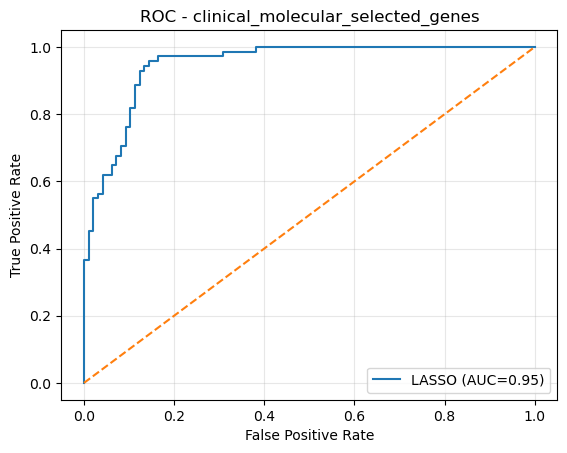

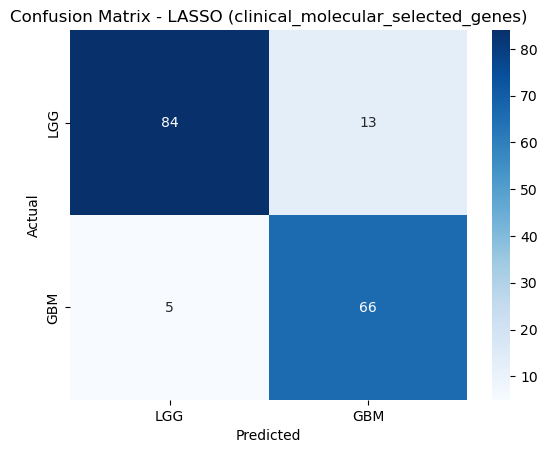

CROSS-VALIDATION (AUC)
Logistic: 0.844 ± 0.023
LASSO: 0.843 ± 0.024
SVM: 0.850 ± 0.025
RandomForest: 0.786 ± 0.033
XGBoost: 0.802 ± 0.028

 Mejor modelo (CV): SVM

 Test evaluation

 Dataset: No_IDH1_1
 Model: SVM
Accuracy: 0.804
Precision: 0.75
Recall (Sensibilidad): 0.803
F1-score: 0.776
Kappa: 0.601
AUC: 0.892
Specificity: 0.804
Confusion Matrix:
 [[78 19]
 [14 57]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.83        97
           1       0.75      0.80      0.78        71

    accuracy                           0.80       168
   macro avg       0.80      0.80      0.80       168
weighted avg       0.81      0.80      0.80       168



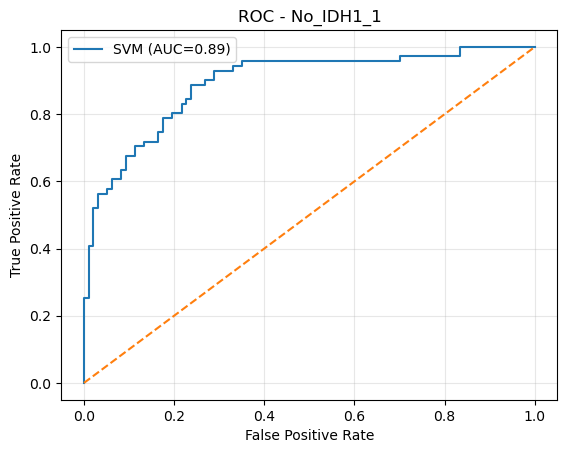

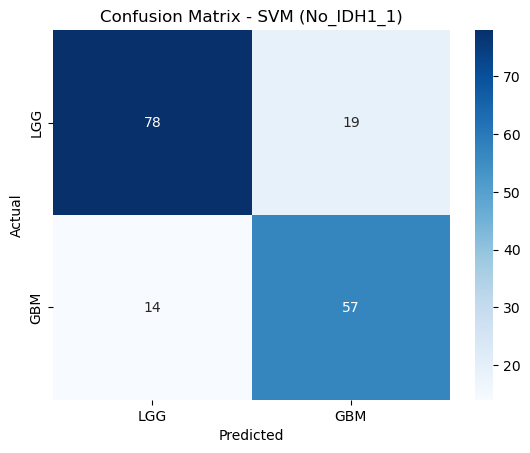

CROSS-VALIDATION (AUC)
Logistic: 0.899 ± 0.017
LASSO: 0.901 ± 0.018
SVM: 0.885 ± 0.037
RandomForest: 0.861 ± 0.029
XGBoost: 0.880 ± 0.033

 Mejor modelo (CV): LASSO

 Test evaluation

 Dataset: clinical_molecular_top_genes
 Model: LASSO
Accuracy: 0.899
Precision: 0.838
Recall (Sensibilidad): 0.944
F1-score: 0.887
Kappa: 0.796
AUC: 0.94
Specificity: 0.866
Confusion Matrix:
 [[84 13]
 [ 4 67]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91        97
           1       0.84      0.94      0.89        71

    accuracy                           0.90       168
   macro avg       0.90      0.90      0.90       168
weighted avg       0.91      0.90      0.90       168



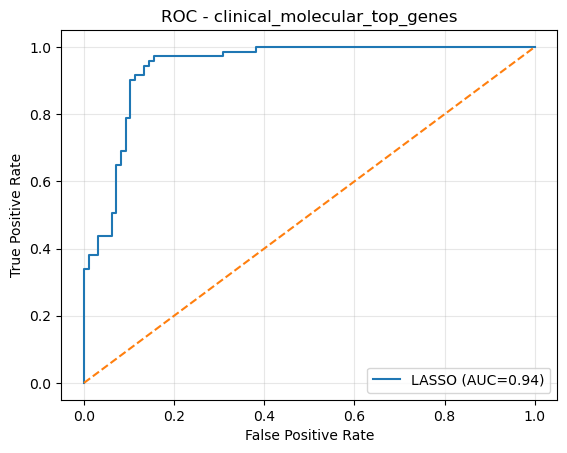

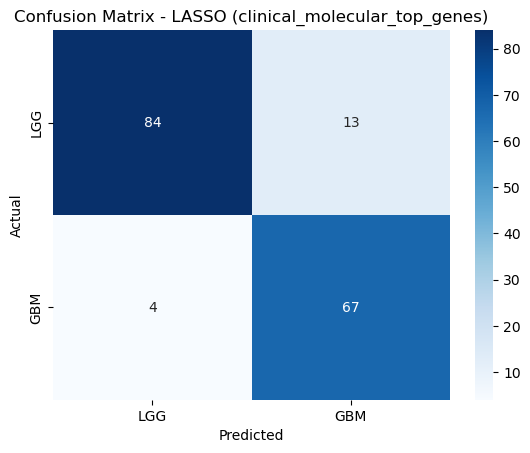

CROSS-VALIDATION (AUC)
Logistic: 0.813 ± 0.021
LASSO: 0.814 ± 0.022
SVM: 0.793 ± 0.018
RandomForest: 0.716 ± 0.032
XGBoost: 0.755 ± 0.027

 Mejor modelo (CV): LASSO

 Test evaluation

 Dataset: clinical_only
 Model: LASSO
Accuracy: 0.756
Precision: 0.721
Recall (Sensibilidad): 0.69
F1-score: 0.705
Kappa: 0.497
AUC: 0.812
Specificity: 0.804
Confusion Matrix:
 [[78 19]
 [22 49]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79        97
           1       0.72      0.69      0.71        71

    accuracy                           0.76       168
   macro avg       0.75      0.75      0.75       168
weighted avg       0.75      0.76      0.76       168



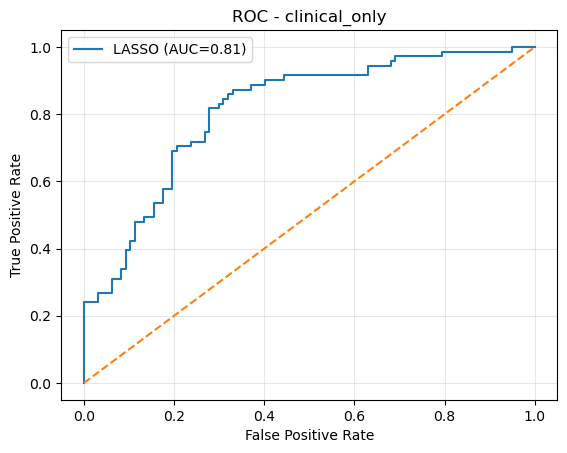

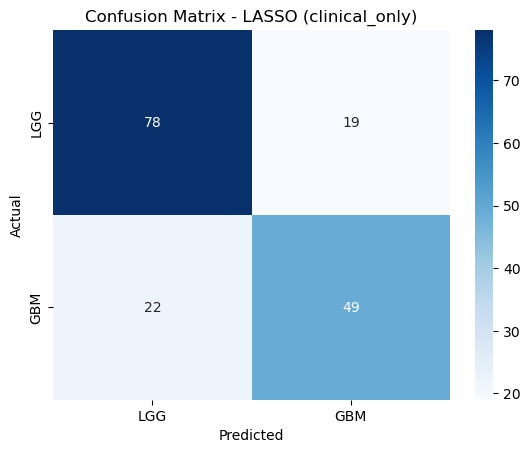


El mejor modelo global fue: LASSO
Con el dataset: clinical_molecular_selected_genes
Obteniendo un AUC máximo de: 0.9480180049368376


In [282]:
# Definición de validación cruzada (5 folds estratificados)
# Se mantuvo la misma semilla aleatoria utilizada en análisis previos (123) 
# para asegurar consistencia y reproducibilidad entre experimentos.
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)

results = [] # Tabla de resultado de mis modelos

# Mejor modelo GLOBAL (SHAP)
global_best_model = None
global_best_name = None
global_best_dataset = None
global_best_auc = 0

trained_models = {} # Para la app

# LOOP PRINCIPAL
for dataset_name, features in datasets.items():

    # Selección de las variables
    X = data[features]
    
    # División de los datos en 80% train y 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.2, # 20% de los datos se reserva para test
        random_state = 123, # Semilla aleatoria para garantizar reproducibilidad
        stratify = y # Mantiene la proporción de clases (LGG/GBM) en train y test
    )

    categorical_features = [col for col in ["Race", "Gender"] if col in features] # Variables categóricas
    numerical_features = [col for col in features if col not in categorical_features] # Variables numéricas

    # Preprocesador dinámico
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])


    # Modelos
    # 1. Regresión logística 
    log_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ])
    # 2. LASSO 
    lasso_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))
    ])
    # 3. SVM
    svm_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", SVC(probability=True))
    ])

    # 4. RF
    rf_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=123))
    ])

    # 5. XGBoost 
    xgb_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(eval_metric='logloss', random_state=123))
    ])
    
    models = {
        "Logistic": log_pipeline,
        "LASSO": lasso_pipeline,
        "SVM": svm_pipeline,
        "RandomForest": rf_pipeline,
        "XGBoost": xgb_pipeline
    }

    # Cross-validation para comparar los modelos. 
    best_model = None # Guarda el mejor modelo.
    best_model_name = None # Guarda su nombre.
    best_cv_auc = 0 # Guarda su mejor AUC.
    
    print("CROSS-VALIDATION (AUC)")

    for name, model in models.items():
        # Evaluar el modelo de forma robusta.
        scores = cross_val_score(model, X_train, y_train, cv = cv, scoring = 'roc_auc') 
        mean_auc = scores.mean() # Decide el mejor.
        std_auc = scores.std() # Desviación estandar.
        
        print(f"{name}: {mean_auc:.3f} ± {std_auc:.3f}") 

        if mean_auc > best_cv_auc:
            best_cv_auc = mean_auc
            best_model = model
            best_model_name = name
            
    print(f"\n Mejor modelo (CV): {best_model_name}")

    # OPTIMIZACIÓN
    # GRIDSEARCH  PARA RF y XGBoost.
    if best_model_name == "RandomForest":

        param_grid = {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10]
        }

        grid = GridSearchCV(rf_pipeline, param_grid, cv = cv, scoring = "roc_auc")
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

    elif best_model_name == "XGBoost":

        param_grid = {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.01, 0.1]
        }

        grid = GridSearchCV(xgb_pipeline, param_grid, cv = cv, scoring = "roc_auc")
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

    else:
        best_model = models[best_model_name]
    
    # Entrenar
    best_model.fit(X_train, y_train)

    # Guardar modelo entrenado para Streamlit
    trained_models[dataset_name] = best_model
    
    print("\n Test evaluation")
    # Evaluar el modelo.
    evaluate_model(best_model_name, best_model, X_test, y_test, dataset_name)

        
    # VISUALIZACIÓN DE RESULTADOS MEDIANTE GRÁFICAS.
    # ROC CURVES
    y_prob = best_model.predict_proba(X_test)[:,1] # prediciiones
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob) # prediciiones

    # Guardar mejor modelo global
    if auc > global_best_auc:
        global_best_auc = auc
        global_best_model = best_model
        global_best_name = best_model_name
        global_best_dataset = dataset_name
        global_X_test = X_test
    
    
    plt.figure()
    plt.plot(fpr, tpr, label = f"{best_model_name} (AUC={auc:.2f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - {dataset_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    # Matriz de confusión (solo para el mejor modelo)
    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm, 
        annot = True, 
        fmt = "d", 
        cmap = "Blues", 
        xticklabels = ["LGG", "GBM"],
        yticklabels = ["LGG", "GBM"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {best_model_name} ({dataset_name})")
    plt.show()

print(f"\n ==================================================")
print(f"El mejor modelo global fue: {global_best_name}")
print(f"Con el dataset: {global_best_dataset}")
print(f"Obteniendo un AUC máximo de: {global_best_auc}")

# 6. Resultados finales

In [284]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by = "AUC", ascending = False).round(3)
results_df = results_df.reset_index(drop=True)
results_df



,Dataset,Model,Accuracy,Precision,Sensitivity,F1,Kappa,AUC,Specificity
0,clinical_molecular_selected_genes,LASSO,0.893,0.835,0.930,0.880,0.784,0.948,0.866
1,clinical_molecular_top_genes,LASSO,0.899,0.838,0.944,0.887,0.796,0.940,0.866
2,top_genes,XGBoost,0.869,0.795,0.930,0.857,0.738,0.914,0.825
3,all_genes,XGBoost,0.881,0.807,0.944,0.870,0.761,0.913,0.835
4,selected_genes,XGBoost,0.875,0.798,0.944,0.865,0.750,0.907,0.825
5,No_IDH1_1,SVM,0.804,0.750,0.803,0.776,0.601,0.892,0.804
6,clinical_only,LASSO,0.756,0.721,0.690,0.705,0.497,0.812,0.804


# 7. Interpretabilidad SHAP

In [285]:
# Transformar datos test
X_test_transformed = global_best_model.named_steps["preprocess"].transform(global_X_test)

In [286]:
# Obtener nombres de variables
feature_names = global_best_model.named_steps["preprocess"].get_feature_names_out()

In [287]:
# Convertir a DataFrame
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns = feature_names) 

In [288]:
# Obtener el mejor modelo global 
model = global_best_model.named_steps["model"]

In [289]:
# Crear explainer
explainer = shap.Explainer(model, X_test_transformed_df)

In [290]:
# Calcular valores SHAP del mejor modelo
shap_values = explainer(X_test_transformed_df)

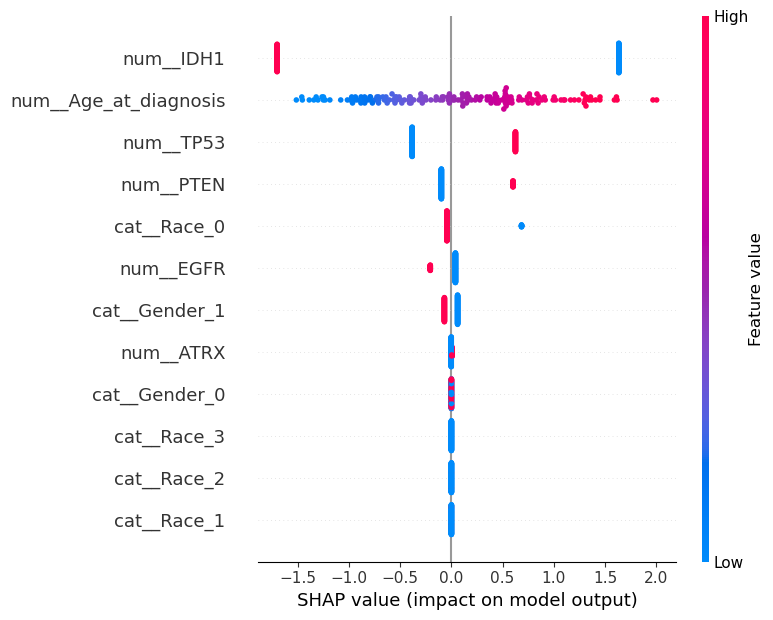

In [291]:
# Ggráfica resumen del mejor modelo global: Beeswarm Plots
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type = "dot"
)

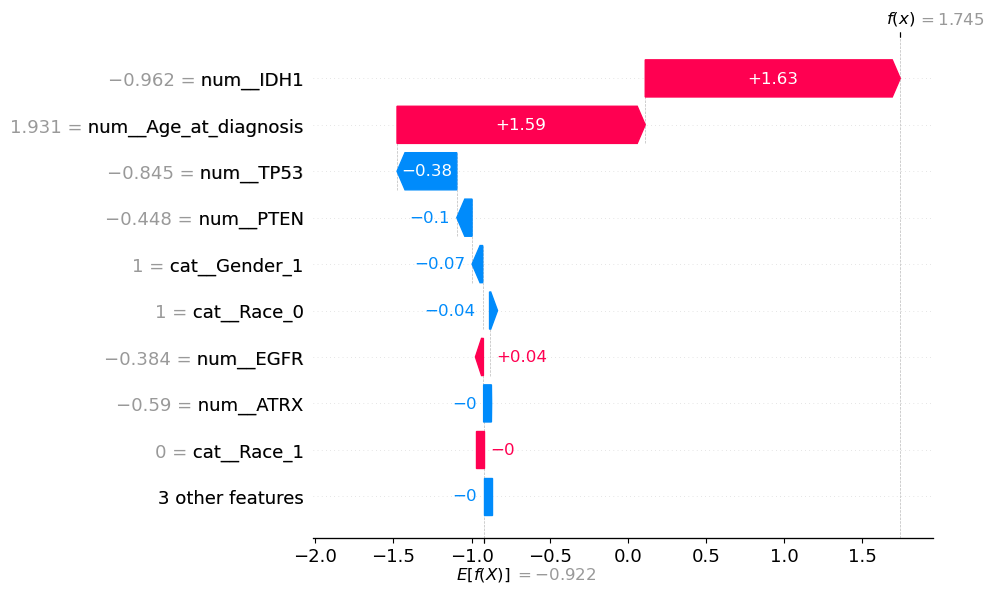

In [292]:
# Ggráfica resumen del mejor modelo global: Waterfall Plot
shap.plots.waterfall(shap_values[0])

In [293]:
# SHAP para clinical_only
# Transformar datos test
X_test_clinical = trained_models["clinical_only"].named_steps["preprocess"].transform(global_X_test[clinical_var])

In [294]:
# Obtener nombres de variables
feature_names_clinical = trained_models["clinical_only"].named_steps["preprocess"].get_feature_names_out()

In [295]:
# Convertir a DataFrame
X_test_clinical_df = pd.DataFrame(X_test_clinical, columns = feature_names_clinical)

In [296]:
# Obtener modelo clinical_only
model_clinical = trained_models["clinical_only"].named_steps["model"]

In [297]:
# Crear explainer
explainer_clinical = shap.Explainer(model_clinical, X_test_clinical_df)

In [298]:
# Calcular SHAP values
shap_values_clinical = explainer_clinical(X_test_clinical_df)

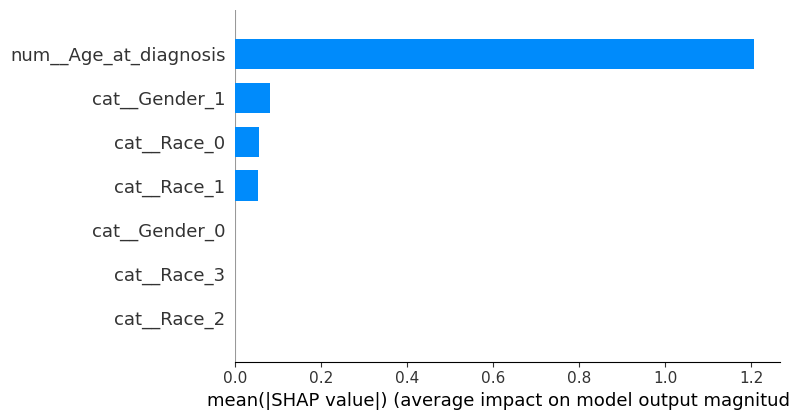

In [300]:
# Ggráfica resumen para clinical_only: Bar plot
shap.summary_plot(
    shap_values_clinical,
    X_test_clinical_df,
    plot_type = "bar"
)

In [301]:
# SHAP para clinical_molecular_top_genes
# Transformar datos test
X_test_molecular = trained_models["clinical_molecular_top_genes"].named_steps["preprocess"].transform(
    global_X_test[clinical_molecular_top_genes])

In [302]:
# Obtener nombres de variables
feature_names_molecular = trained_models["clinical_molecular_top_genes"].named_steps["preprocess"].get_feature_names_out()

In [303]:
# Convertir a DataFrame
X_test_molecular_df = pd.DataFrame(
    X_test_molecular,
    columns = feature_names_molecular
)

In [304]:
# Obtener modelo
model_molecular = trained_models["clinical_molecular_top_genes"].named_steps["model"]

In [305]:
# Crear explainer
explainer_molecular = shap.Explainer(model_molecular, X_test_molecular_df)

In [306]:
# Calcular SHAP values
shap_values_molecular = explainer_molecular(X_test_molecular_df)

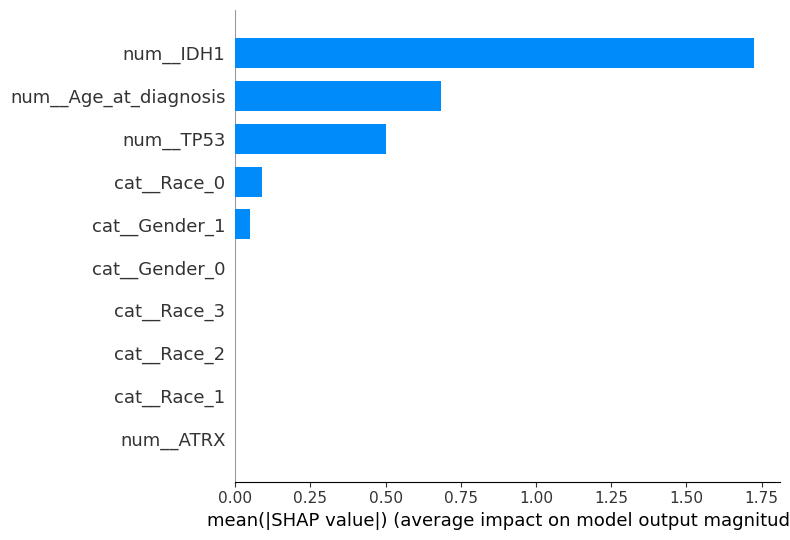

In [307]:
# Ggráfica resumen para clinical_molecular_top_genes: Bar plot
shap.summary_plot(
    shap_values_molecular,
    X_test_molecular_df,
    plot_type = "bar"
)

In [309]:
# GUARDAR MODELOS PARA LA APP
# 1. Modelo clinical_only
joblib.dump(trained_models["clinical_only"], "clinical_only_model.pkl")

# 2. Modelo 3 genes + variables clínicas (clinical_molecular_top_genes)
joblib.dump(trained_models["clinical_molecular_top_genes"], "clinical_molecular_top_genes_model.pkl")

# 2. Modelo 5 genes + variables clínicas (clinical_molecular_selected_genes)
joblib.dump(trained_models["clinical_molecular_selected_genes"], "clinical_molecular_selected_genes_model.pkl")


['clinical_molecular_selected_genes_model.pkl']